In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("email_spam_detection.csv")
df.head()

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
0,1,,Meeting,NaN,99,-1,7,0,0
1,2,user1@outlook.com,Security Alert,87.0,2,3,8,0,0
2,3,user2@yahoo.com,Win Prize,69.0,0,3,8,0,0
3,4,user3@gmail.com,Invoice,61.0,0,3,8,0,0
4,5,user4@company.com,Meeting,99.0,2,3,5,0,0


In [3]:
print("Shape:", df.shape)

df.info()

df.describe(include="all")

Shape: (7000, 9)
<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Email_ID           7000 non-null   int64  
 1   Sender_Email       6999 non-null   str    
 2   Subject            7000 non-null   str    
 3   Email_Length       6959 non-null   float64
 4   Num_Links          7000 non-null   int64  
 5   Num_Special_Chars  7000 non-null   int64  
 6   Capital_Words      7000 non-null   int64  
 7   Has_Attachment     7000 non-null   int64  
 8   Spam               7000 non-null   int64  
dtypes: float64(1), int64(6), str(2)
memory usage: 694.4 KB


,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
count,7000.000000,6999,7000,6959.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
unique,NaN,6973,8,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,,Win Prize,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,27,937,NaN,NaN,NaN,NaN,NaN,NaN
mean,3500.500000,NaN,NaN,110.567898,2.454571,6.636429,12.199714,0.260714,0.305143
std,2020.870275,NaN,NaN,52.353566,5.319235,6.123388,15.169749,0.439056,0.460501
min,1.000000,NaN,NaN,20.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,1750.750000,NaN,NaN,70.000000,0.000000,2.000000,3.000000,0.000000,0.000000
50%,3500.500000,NaN,NaN,95.000000,1.000000,4.000000,6.000000,0.000000,0.000000
75%,5250.250000,NaN,NaN,158.000000,3.000000,11.000000,10.250000,1.000000,1.000000


In [4]:
df.isnull().sum()

Email_ID              0
Sender_Email          1
Subject               0
Email_Length         41
Num_Links             0
Num_Special_Chars     0
Capital_Words         0
Has_Attachment        0
Spam                  0
dtype: int64

In [5]:
df["Sender_Email"] = df["Sender_Email"].replace("", np.nan)
df["Sender_Email"] = df["Sender_Email"].replace(" ", np.nan)

df["Sender_Email"].isnull().sum()

np.int64(28)

In [6]:
print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

Duplicate Rows: 0


In [7]:
print(df.dtypes)

Email_ID               int64
Sender_Email             str
Subject                  str
Email_Length         float64
Num_Links              int64
Num_Special_Chars      int64
Capital_Words          int64
Has_Attachment         int64
Spam                   int64
dtype: object


In [8]:
df["Email_Length"] = pd.to_numeric(df["Email_Length"], errors="coerce")

In [9]:
print(df[df["Email_Length"].isnull()])

      Email_ID          Sender_Email               Subject  Email_Length  \
0            1                   NaN               Meeting           NaN   
173        174   user173@outlook.com        Project Update           NaN   
346        347   user346@outlook.com             Greetings           NaN   
519        520     user519@gmail.com             Greetings           NaN   
692        693     user692@gmail.com               Meeting           NaN   
865        866     user865@gmail.com               Invoice           NaN   
1038      1039  user1038@company.com             Win Prize           NaN   
1211      1212  user1211@company.com  Account Verification           NaN   
1384      1385  user1384@outlook.com        Project Update           NaN   
1557      1558  user1557@outlook.com  Account Verification           NaN   
1730      1731  user1730@company.com             Greetings           NaN   
1903      1904  user1903@outlook.com             Greetings           NaN   
2076      20

In [10]:
print(df[df["Num_Special_Chars"] == -1])

      Email_ID          Sender_Email               Subject  Email_Length  \
0            1                   NaN               Meeting           NaN   
311        312     user311@yahoo.com        Security Alert          40.0   
622        623   user622@company.com               Meeting         184.0   
933        934     user933@yahoo.com               Meeting          98.0   
1244      1245  user1244@company.com             Greetings         180.0   
1555      1556    user1555@gmail.com                 Offer          67.0   
1866      1867  user1866@outlook.com               Invoice          64.0   
2177      2178    user2177@yahoo.com               Invoice         156.0   
2488      2489  user2488@company.com               Meeting          88.0   
2799      2800    user2799@yahoo.com               Meeting         169.0   
3110      3111  user3110@company.com  Account Verification          86.0   
3421      3422  user3421@outlook.com             Win Prize         224.0   
3732      37

In [11]:
df["Num_Special_Chars"] = df["Num_Special_Chars"].replace(-1, np.nan)

In [12]:
print(df[df["Num_Links"] == 99])

df["Num_Links"] = df["Num_Links"].replace(99, np.nan)

      Email_ID          Sender_Email               Subject  Email_Length  \
0            1                   NaN               Meeting           NaN   
419        420   user419@outlook.com        Project Update         221.0   
838        839     user838@gmail.com  Account Verification         190.0   
1257      1258  user1257@outlook.com               Meeting          75.0   
1676      1677    user1676@gmail.com        Project Update          88.0   
2095      2096  user2095@outlook.com                 Offer         169.0   
2514      2515  user2514@company.com               Meeting          52.0   
2933      2934    user2933@yahoo.com             Greetings          23.0   
3352      3353    user3352@gmail.com             Win Prize         120.0   
3771      3772  user3771@outlook.com               Invoice          27.0   
4190      4191    user4190@yahoo.com               Invoice         161.0   
4609      4610    user4609@yahoo.com               Meeting          76.0   
5028      50

In [13]:
df["Email_Length"].fillna(df["Email_Length"].median(), inplace=True)

df["Num_Special_Chars"].fillna(df["Num_Special_Chars"].median(), inplace=True)

df["Num_Links"].fillna(df["Num_Links"].median(), inplace=True)

df["Sender_Email"].fillna("Unknown", inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7572\413402482.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Email_Length"].fillna(df["Email_Length"].median(), inplace=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_7572\413402482.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chai

0                    Unknown
1          user1@outlook.com
2            user2@yahoo.com
3            user3@gmail.com
4          user4@company.com
                ...         
6995      user6995@gmail.com
6996      user6996@yahoo.com
6997      user6997@gmail.com
6998    user6998@outlook.com
6999    user6999@company.com
Name: Sender_Email, Length: 7000, dtype: str

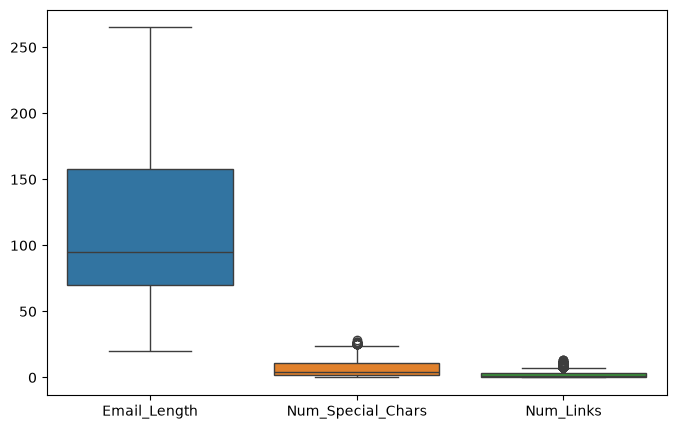

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[["Email_Length","Num_Special_Chars","Num_Links"]])
plt.show()

In [15]:
Q1 = df["Email_Length"].quantile(0.25)
Q3 = df["Email_Length"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Email_Length"] < lower) | (df["Email_Length"] > upper)]

print(outliers)

Empty DataFrame
Columns: [Email_ID, Sender_Email, Subject, Email_Length, Num_Links, Num_Special_Chars, Capital_Words, Has_Attachment, Spam]
Index: []


Spam
0    4864
1    2136
Name: count, dtype: int64


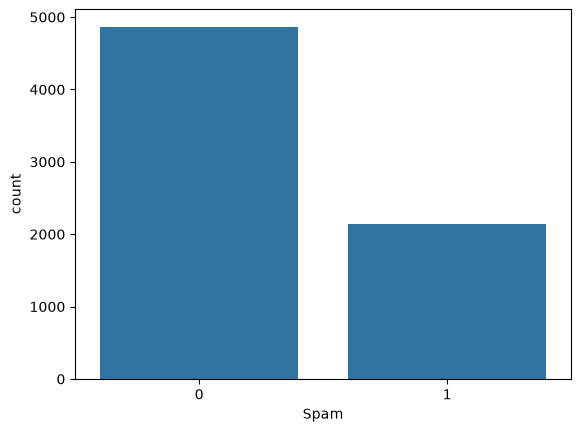

In [16]:
print(df["Spam"].value_counts())

sns.countplot(x="Spam", data=df)
plt.show()

In [17]:
df.to_csv("cleaned_email_spam_detection.csv", index=False)

print("Cleaned Dataset Saved Successfully!")

Cleaned Dataset Saved Successfully!


In [18]:
df.head()

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
0,1,NaN,Meeting,NaN,NaN,NaN,7,0,0
1,2,user1@outlook.com,Security Alert,87.0,2.0,3.0,8,0,0
2,3,user2@yahoo.com,Win Prize,69.0,0.0,3.0,8,0,0
3,4,user3@gmail.com,Invoice,61.0,0.0,3.0,8,0,0
4,5,user4@company.com,Meeting,99.0,2.0,3.0,5,0,0


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Email_ID           7000 non-null   int64  
 1   Sender_Email       6972 non-null   str    
 2   Subject            7000 non-null   str    
 3   Email_Length       6959 non-null   float64
 4   Num_Links          6983 non-null   float64
 5   Num_Special_Chars  6977 non-null   float64
 6   Capital_Words      7000 non-null   int64  
 7   Has_Attachment     7000 non-null   int64  
 8   Spam               7000 non-null   int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 694.4 KB


In [20]:
print(df.isnull().sum())

Email_ID              0
Sender_Email         28
Subject               0
Email_Length         41
Num_Links            17
Num_Special_Chars    23
Capital_Words         0
Has_Attachment        0
Spam                  0
dtype: int64


In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Sender_Email"] = le.fit_transform(df["Sender_Email"])
df["Subject"] = le.fit_transform(df["Subject"])

In [22]:
df["Has_Attachment"] = le.fit_transform(df["Has_Attachment"])

In [23]:
X = df.drop("Spam", axis=1)

print(X.isnull().sum())

Email_ID              0
Sender_Email          0
Subject               0
Email_Length         41
Num_Links            17
Num_Special_Chars    23
Capital_Words         0
Has_Attachment        0
dtype: int64


In [24]:
df["Sender_Email"] = df["Sender_Email"].fillna("Unknown")

df["Email_Length"] = df["Email_Length"].fillna(df["Email_Length"].median())

df["Num_Special_Chars"] = df["Num_Special_Chars"].replace(-1, np.nan)
df["Num_Special_Chars"] = df["Num_Special_Chars"].fillna(df["Num_Special_Chars"].median())

df["Num_Links"] = df["Num_Links"].replace(99, np.nan)
df["Num_Links"] = df["Num_Links"].fillna(df["Num_Links"].median())

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Sender_Email"] = le.fit_transform(df["Sender_Email"])
df["Subject"] = le.fit_transform(df["Subject"])

In [26]:
X = df.drop("Spam", axis=1)
y = df["Spam"]

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [30]:
y_pred = model.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9992857142857143


In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[966   0]
 [  1 433]]


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       966
           1       1.00      1.00      1.00       434

    accuracy                           1.00      1400
   macro avg       1.00      1.00      1.00      1400
weighted avg       1.00      1.00      1.00      1400



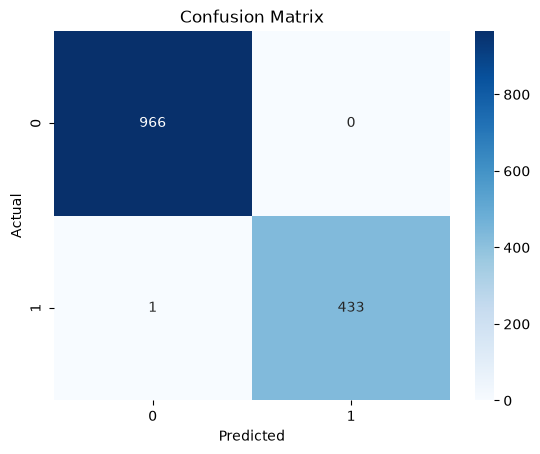

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [35]:
new_email = pd.DataFrame({
    "Email_ID": [7001],
    "Sender_Email": [100],
    "Subject": [200],
    "Email_Length": [250],
    "Num_Links": [3],
    "Num_Special_Chars": [5],
    "Capital_Words": [10],
    "Has_Attachment": [1]
})

new_email = scaler.transform(new_email)

prediction = model.predict(new_email)

print("Prediction:", prediction)

Prediction: [1]


In [36]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")

print(scores)

C:\Users\ASUS\OneDrive\Desktop\summer internship\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[0.99785714 0.99785714 1.         0.99928571 1.        ]


In [37]:
print("Average Accuracy:", scores.mean())

Average Accuracy: 0.999


In [38]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Cross Validation Accuracy": [scores.mean()]
})

results

,Model,Accuracy,Cross Validation Accuracy
0,Logistic Regression,0.999286,0.999


In [39]:
import joblib

joblib.dump(model, "spam_detection_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully


In [40]:
df.to_csv("cleaned_email_spam_detection.csv", index=False)

In [41]:
new_email = pd.DataFrame({
    "Email_ID": [7001],
    "Sender_Email": [100],
    "Subject": [200],
    "Email_Length": [250],
    "Num_Links": [2],
    "Num_Special_Chars": [5],
    "Capital_Words": [8],
    "Has_Attachment": [1]
})

In [42]:
new_email = scaler.transform(new_email)

In [43]:
prediction = model.predict(new_email)

if prediction[0] == 1:
    print("Spam Email")
else:
    print("Not Spam Email")

Spam Email


In [44]:
probability = model.predict_proba(new_email)

print("Probability:", probability)

Probability: [[4.94801042e-07 9.99999505e-01]]


In [45]:
import joblib

joblib.dump(model, "spam_detection_model.pkl")

['spam_detection_model.pkl']

In [46]:
df.to_csv("cleaned_email_spam_detection.csv", index=False)

In [47]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.9978571428571429


In [48]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9985714285714286


In [49]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.9992857142857143


In [50]:
from sklearn.svm import SVC

svm_model = SVC(probability=True)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

C:\Users\ASUS\OneDrive\Desktop\summer internship\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM Accuracy: 0.9992857142857143


In [51]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))

Gradient Boosting Accuracy: 0.9971428571428571


In [52]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, gb_pred)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,0.999286
3,KNN,0.999286
4,SVM,0.999286
2,Random Forest,0.998571
1,Decision Tree,0.997857
5,Gradient Boosting,0.997143


In [53]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [54]:
from sklearn.model_selection import cross_val_score

score1 = cross_val_score(model, X, y, cv=5, scoring="accuracy")
score2 = cross_val_score(dt_model, X, y, cv=5, scoring="accuracy")
score3 = cross_val_score(rf_model, X, y, cv=5, scoring="accuracy")
score4 = cross_val_score(knn_model, X, y, cv=5, scoring="accuracy")
score5 = cross_val_score(svm_model, X, y, cv=5, scoring="accuracy")
score6 = cross_val_score(gb_model, X, y, cv=5, scoring="accuracy")

C:\Users\ASUS\OneDrive\Desktop\summer internship\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\ASUS\OneDrive\Desktop\summer internship\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\ASUS\OneDrive\Desktop\summer internship\venv\Lib\site-packages\sklea

In [55]:
cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM",
        "Gradient Boosting"
    ],
    "Cross Validation Accuracy": [
        score1.mean(),
        score2.mean(),
        score3.mean(),
        score4.mean(),
        score5.mean(),
        score6.mean()
    ]
})

cv_results.sort_values(by="Cross Validation Accuracy", ascending=False)

,Model,Cross Validation Accuracy
2,Random Forest,0.999429
5,Gradient Boosting,0.999286
0,Logistic Regression,0.999000
1,Decision Tree,0.862000
4,SVM,0.706286
3,KNN,0.553429


In [56]:
sample = X.iloc[[0]]

print("Actual:", y.iloc[0])
print("Prediction:", rf_model.predict(sample))
print("Probability:", rf_model.predict_proba(sample))

Actual: 0
Prediction: [1]
Probability: [[0. 1.]]


C:\Users\ASUS\OneDrive\Desktop\summer internship\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ASUS\OneDrive\Desktop\summer internship\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [57]:
sample = X.iloc[[0]]

print("Sample Data:")
print(sample)

print("Actual:", y.iloc[0])
print("Predicted:", model.predict(sample))
print("Probability:", model.predict_proba(sample))

Sample Data:
   Email_ID  Sender_Email  Subject  Email_Length  Num_Links  \
0         1          6972        3          95.0        1.0   

   Num_Special_Chars  Capital_Words  Has_Attachment  
0                4.0              7               0  
Actual: 0
Predicted: [1]
Probability: [[0. 1.]]


C:\Users\ASUS\OneDrive\Desktop\summer internship\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\ASUS\OneDrive\Desktop\summer internship\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [58]:
sample = X.iloc[[0]]
sample_scaled = scaler.transform(sample)

print("Actual:", y.iloc[0])
print("Predicted:", model.predict(sample_scaled))
print("Probability:", model.predict_proba(sample_scaled))

Actual: 0
Predicted: [0]
Probability: [[9.99189346e-01 8.10653775e-04]]


In [59]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "CV Accuracy": [
        score1.mean(),
        score2.mean(),
        score3.mean(),
        score4.mean(),
        score5.mean(),
        score6.mean()
    ]
})

final_results.sort_values(by="CV Accuracy", ascending=False)

,Model,Accuracy,CV Accuracy
2,Random Forest,0.998571,0.999429
5,Gradient Boosting,0.997143,0.999286
0,Logistic Regression,0.999286,0.999000
1,Decision Tree,0.997857,0.862000
4,SVM,0.999286,0.706286
3,KNN,0.999286,0.553429


In [60]:
df.to_csv("cleaned_email_spam_detection.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [61]:
best_model = final_results.sort_values(
    by="CV Accuracy",
    ascending=False
).iloc[0]

print("Email Spam Detection Project Completed Successfully!")
print("Best Performing Model:", best_model["Model"])
print("Cross Validation Accuracy:", best_model["CV Accuracy"])

Email Spam Detection Project Completed Successfully!
Best Performing Model: Random Forest
Cross Validation Accuracy: 0.9994285714285714


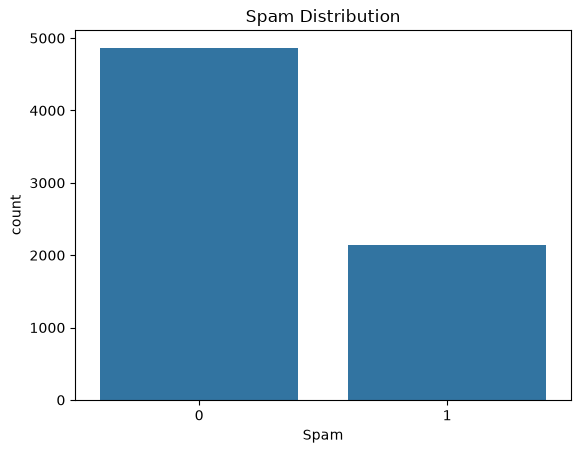

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Spam", data=df)
plt.title("Spam Distribution")
plt.show()

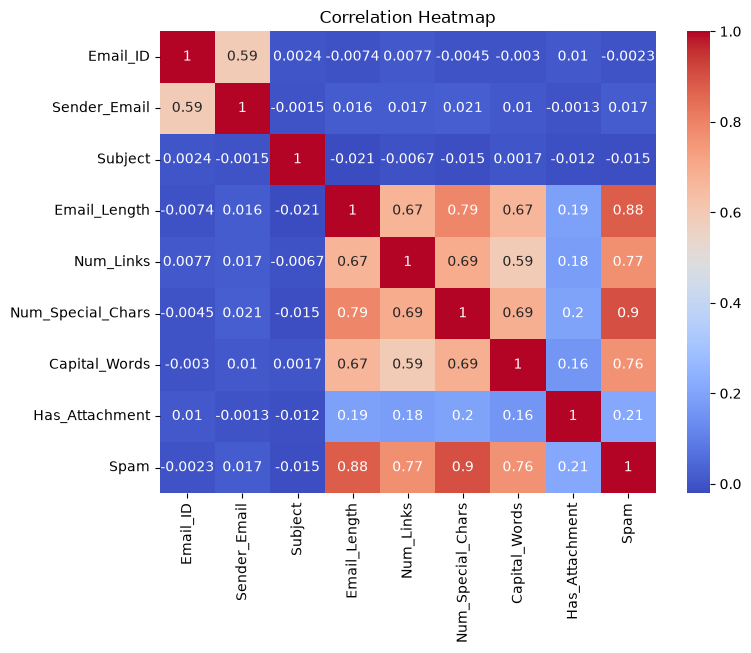

In [63]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

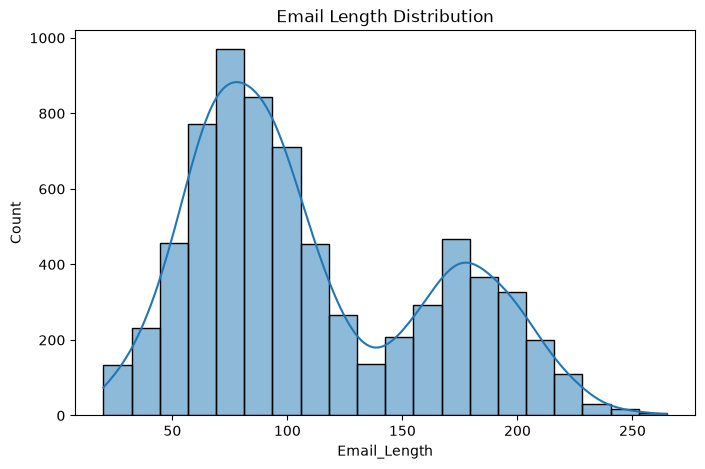

In [64]:
plt.figure(figsize=(8,5))

sns.histplot(df["Email_Length"], bins=20, kde=True)

plt.title("Email Length Distribution")
plt.show()

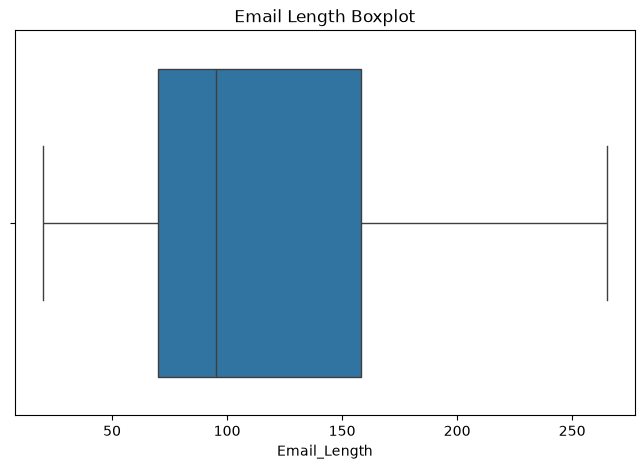

In [65]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Email_Length"])

plt.title("Email Length Boxplot")
plt.show()

In [66]:
import joblib

joblib.dump(model, "spam_detection_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


             Feature  Importance
5  Num_Special_Chars    0.382922
3       Email_Length    0.300555
6      Capital_Words    0.205229
4          Num_Links    0.099257
7     Has_Attachment    0.006701
1       Sender_Email    0.002416
0           Email_ID    0.002009
2            Subject    0.000910


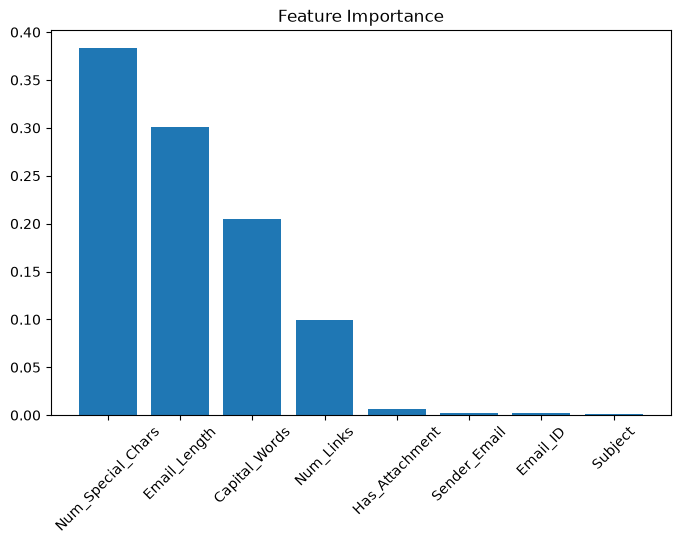

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(8,5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

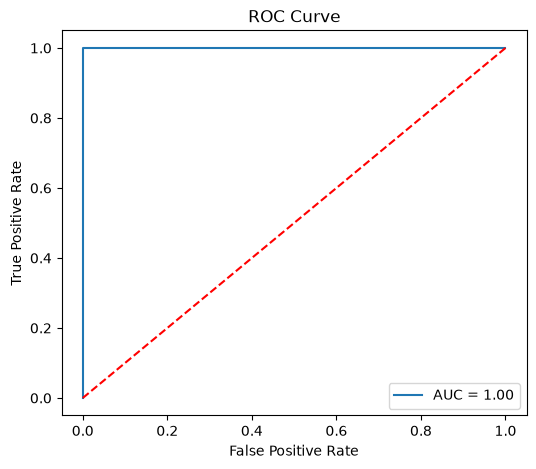

In [68]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [69]:
best_model = final_results.sort_values(
    by="CV Accuracy",
    ascending=False
).iloc[0]

print("========== PROJECT SUMMARY ==========")
print("Dataset Cleaned Successfully")
print("All ML Models Trained Successfully")
print("Best Model :", best_model["Model"])
print("Accuracy :", best_model["Accuracy"])
print("Cross Validation Accuracy :", best_model["CV Accuracy"])
print("Project Completed Successfully!")

========== PROJECT SUMMARY ==========
Dataset Cleaned Successfully
All ML Models Trained Successfully
Best Model : Random Forest
Accuracy : 0.9985714285714286
Cross Validation Accuracy : 0.9994285714285714
Project Completed Successfully!


In [70]:
import joblib

joblib.dump(model, "spam_detection_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully")

Model Saved Successfully
